In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.graph_objects as go
import networkx as nx

## **Exercise 4 (Graph Visualization in Python)**

In this exercise we will learn how to visualize graphs in Python via plotly and Netwrokx.

### **a) Reading the file and building the correlation matrix**

First, we will read the the breast-cancer-wisconsin.xlsx file. We will choose the median as our imputation model as we did last time.

In [13]:
df = pd.read_excel('breast-cancer-wisconsin.xlsx')

imputer=SimpleImputer(strategy='median')
df_imputed=pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

df=df_imputed #clean data

Now, we can compute the Pearson correlation matrix

In [15]:
corr_mat = df.corr(method='pearson')
print(corr_mat)

                 code  thickness   uniCelS  uniCelShape    marAdh  epiCelSize  \
code         1.000000  -0.055308 -0.041603    -0.041576 -0.064878   -0.045528   
thickness   -0.055308   1.000000  0.644913     0.654589  0.486356    0.521816   
uniCelS     -0.041603   0.644913  1.000000     0.906882  0.705582    0.751799   
uniCelShape -0.041576   0.654589  0.906882     1.000000  0.683079    0.719668   
marAdh      -0.064878   0.486356  0.705582     0.683079  1.000000    0.599599   
epiCelSize  -0.045528   0.521816  0.751799     0.719668  0.599599    1.000000   
bareNuc     -0.092533   0.590008  0.686673     0.707474  0.666971    0.583701   
blaChroma   -0.060051   0.558428  0.755721     0.735948  0.666715    0.616102   
normNuc     -0.052072   0.535835  0.722865     0.719446  0.603352    0.628881   
mitoses     -0.034901   0.350034  0.458693     0.438911  0.417633    0.479101   
class       -0.080226   0.716001  0.817904     0.818934  0.696800    0.682785   

              bareNuc  blaC

This matrix gives us already the information of how our variables relate with each other. However, it is hard to have a general idea by presenting the information using a matrix this large. Therfore, it is highly recommended to visualize it with a graph.

### **b) Correlation graph with a force-directed layout**

This graph we want to build will have the vraibles as nodes. An edge between two nodes will be inserted whenever the correlation is higher than 0,6.

A force-directed layout might be convenient because repulsive and attractive forces effectively reveal dense clusters of strongly correlated variables and isolated nodes that indicate features with weak correlations. Overall, the layout makes the correlation structure and variable connectivity easy to interpret visually.

In [111]:
G = nx.Graph()

# Add the variables as nodes:
for col in corr_mat.columns:
    G.add_node(col)

threshold = 0.6

for i in range(len(corr_mat.columns)):
    for j in range(i+1, len(corr_mat.columns)): #to avoid double counting
        if abs(corr_mat.iloc[i, j]) > threshold: #keeping the correlation above the threshold
            G.add_edge(corr_mat.columns[i], corr_mat.columns[j]) #saving the edge


# Force-directed layout
pos = nx.spring_layout(G,k=3.2,iterations=200, seed=1) # k controls spacing between nodes, iterations controls convergence, seed for reproducibility

# Edge traces:
edge_x = []
edge_y = []

for edge in G.edges():
    node1, node2 = edge
    x0, y0 = pos[node1]
    x1, y1 = pos[node2]
    edge_x.append(x0)
    edge_x.append(x1)
    edge_x.append(None)
    edge_y.append(y0)
    edge_y.append(y1)
    edge_y.append(None)

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    line=dict(width=1, color="rgba(420,120,120,0.75)"),
    hoverinfo='none',
    mode='lines'
)

# Node traces:
node_x = []
node_y = []
label_x = []
label_y = []
label_text = []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    label_x.append(x)
    label_y.append(y - 0.08)   # offset upward
    label_text.append(node)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    marker=dict(size=10, color='lightblue', line_width=2))


label_trace = go.Scatter(
    x=label_x,
    y=label_y,

    mode='text',

    text=label_text,

    textposition='top center',

    hoverinfo='none',

    textfont=dict(
        size=8,
        color='black'
    )
)
    

fig = go.Figure(
    data=[edge_trace, node_trace, label_trace],
    layout=go.Layout(
        title=dict(text='Correlation Graph with a force-directed layout', font=dict(size=16)),

        showlegend=False,
        hovermode='closest',

        margin=dict(b=20, l=5, r=5, t=40),

        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),

        plot_bgcolor='white'
    )
)

fig.show()


For this graph we chose a big enough k so we can interpret and read the correlations within the central cluster but not that big so the large distance to the isolated points is noticeable. 

*Interpretation of the graph:*
We can tell that there is one dense correlated cluster in the center while mitoses and code appear isolated, meaning that these variables do not have correlations above the threshold. Then, there are a few high-connectivity variables in the cluster such as class & blaChroma, uniCelS & blaChroma, epiCelsize & normNuc and some others. The graph also allows as to tell which relations are weaker inside the cluster, e.g, thickness & uniCelShape or non not high enough correlation between variables form inside the cluster, e.g., thickness & epiCelSize. Lastly, the variables that are more centered in the cluster are the ones that are highle related to more other variables.

### **c) Reflecting the magnitude of the correlation**

Now the edges will have different colour intensities to reflect the magnitude of the correlation. Nevertheless, this modification might me even more useful in other kinds of layouts because the force layout already reflects the magnitudes via positions.

To do this we will modify both, the line width and the intensity of the color of the edge. A higher correlation will be reflected in a more intense and wide edge.

In [109]:
G2 = nx.Graph()

# Add the variables as nodes:
for col in corr_mat.columns:
    G2.add_node(col)

threshold = 0.6

for i in range(len(corr_mat.columns)):
    for j in range(i+1, len(corr_mat.columns)):
        if abs(corr_mat.iloc[i, j]) > threshold: 
            G2.add_edge(corr_mat.columns[i], corr_mat.columns[j], weight=corr_mat.iloc[i, j]) #we add the weights


# Force-directed layout
pos = nx.spring_layout(G2,k=3.2,iterations=200, seed=1) # k controls spacing between nodes, iterations controls convergence, seed for reproducibility

# Edge traces:
edge_traces = [] 

for edge in G2.edges(data=True):
    node1, node2, attr = edge
    x0, y0 = pos[node1]
    x1, y1 = pos[node2]

    weight = abs(attr['weight'])
    exaggerated_weight = weight ** 4

    edge_width = exaggerated_weight *3

    edge_color = f"rgba(420, 120, 120, {weight})"

    trace = go.Scatter(
        x=[x0, x1],
        y=[y0, y1],
        line=dict(width=edge_width, color=edge_color),
        hoverinfo='none',
        mode='lines'
    )
    edge_traces.append(trace)


# Node traces:
node_x = []
node_y = []
label_x = []
label_y = []
label_text = []
for node in G2.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    label_x.append(x)
    label_y.append(y - 0.08)   
    label_text.append(node)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    marker=dict(size=10, color='lightblue', line_width=2))


label_trace = go.Scatter(
    x=label_x,
    y=label_y,

    mode='text',

    text=label_text,

    textposition='top center',

    hoverinfo='none',

    textfont=dict(
        size=8,
        color='black'
    )
)
    

fig = go.Figure(
    data=[*edge_traces, node_trace, label_trace],
    layout=go.Layout(
        title=dict(text='Correlation Graph with a force-directed layout', font=dict(size=16)),

        showlegend=False,
        hovermode='closest',

        margin=dict(b=20, l=5, r=5, t=40),

        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),

        plot_bgcolor='white'
    )
)

fig.show()


Now we can learn that the strongest correlation is between uniCelS and uniCelShape.

### **d) Circular layout**

Now we work with a circular layout. Now positions of the nodes do not reflect the stronger or weaker relations. Therfore, our color code has to be more complex. We will color the nodes (variables) depending on the maximum correlation of it:
- Blue node if pmax > 0.9
- Green node if 0.8 < pmax < 0.9
- Orange node if 0.6 < pmax < 0.8
- Gray node if pmax < 0.6

In [94]:

G3 = nx.Graph()

# Add the variables as nodes:
for col in corr_mat.columns:
    G3.add_node(col)

threshold = 0.6

# Add edges with weights
for i in range(len(corr_mat.columns)):
    for j in range(i+1, len(corr_mat.columns)):
        if abs(corr_mat.iloc[i, j]) > threshold: 
            G3.add_edge(corr_mat.columns[i], corr_mat.columns[j], weight=corr_mat.iloc[i, j])

# We replace the diagonal with 0 temporarily to avoid evaluating the correlation of a variable with itself
temp_corr = corr_mat.abs().copy()
np.fill_diagonal(temp_corr.values, 0)

node_colors = []
node_categories = []

for node in G3.nodes():
    # Looking for the maximum absolute correlation of this node with any other
    p_max = temp_corr[node].max()
    
    if p_max > 0.9:
        color = '#1f77b4'  # Blue if ρmax > 0.9
        cat = 'ρmax > 0.9'
    elif 0.8 < p_max <= 0.9:
        color = "#77b421"  # Green if 0.8 < ρmax <= 0.9
        cat = '0.8 < ρmax <= 0.9'
    elif 0.6 < p_max <= 0.8:
        color = "#ec9d27"  # Orange if 0.6 < ρmax <= 0.8
        cat = '0.6 < ρmax <= 0.8'
    else:
        color = '#7f7f7f'  # Gray for the remaining (ρmax <= 0.6)
        cat = 'ρmax <= 0.6'
        
    node_colors.append(color)
    node_categories.append(f"{node} ({cat})")

# Circular layout
pos = nx.circular_layout(G3) 

# Edge traces
edge_traces = []
for edge in G3.edges(data=True):
    node1, node2, attr = edge
    x0, y0 = pos[node1]
    x1, y1 = pos[node2]
    
    weight = abs(attr['weight'])
    
    # Exageramos la diferencia visual con potencia cúbica (como en el paso anterior)
    exaggerated_factor = weight ** 3.5
    edge_width = exaggerated_factor * 4
    edge_color = f"rgba(300, 100, 100, {exaggerated_factor})"
    
    trace = go.Scatter(
        x=[x0, x1], y=[y0, y1],
        line=dict(width=edge_width, color=edge_color),
        hoverinfo='none',
        mode='lines'
    )
    edge_traces.append(trace)

# Node traces:
node_x = []
node_y = []
for node in G3.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    text=node_categories, 
    marker=dict(
        size=14, 
        color=node_colors, 
        line=dict(width=1.5, color='white')
    )
)

# Label traces:
label_x = []
label_y = []
label_text = []
for node in G3.nodes():
    x, y = pos[node]
    label_x.append(x)
    label_y.append(y - 0.08)   
    label_text.append(node)

label_trace = go.Scatter(
    x=label_x, y=label_y,
    mode='text',
    text=label_text,
    textposition='middle center',
    hoverinfo='none',
    textfont=dict(size=9, color='black')
)

# Figure and Layout
fig = go.Figure(
    data=[*edge_traces, node_trace, label_trace],
    layout=go.Layout(
        title=dict(text='Circular Correlation Graph', font=dict(size=16)),
        showlegend=False,
        hovermode='closest',
        margin=dict(b=40, l=40, r=40, t=60), 
        xaxis=dict(showgrid=True, gridcolor="#f0f0f0", gridwidth=1, zeroline=True, zerolinecolor="#ffffff",showticklabels=False),
        yaxis=dict(showgrid=True, gridcolor="#f0f0f0", gridwidth=1, zeroline=True, zerolinecolor="#ffffff", showticklabels=False),
        plot_bgcolor="#dbe0e7"
    )
)

fig.show()

As we said, implementing a proper color code for the nodes and intensity for the edges is really helpful depending on the layout.

### **e) Questions**

- Only code and mitoses are disconnected. The code being not correlated to any variable means that the indexation of the units is ignorable and independet of the measurments. This could also be appreciated in the correlation matrix because the correlation values were all reallly small. To interpret the non-correlation of the variable mitoses, lets take a look at the histogram of the variable:

(array([579.,  35.,  33.,  12.,   6.,   3.,   9.,   8.,   0.,  14.]),
 array([ 1. ,  1.9,  2.8,  3.7,  4.6,  5.5,  6.4,  7.3,  8.2,  9.1, 10. ]),
 <BarContainer object of 10 artists>)

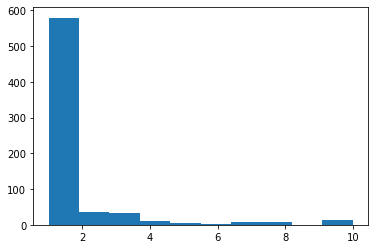

In [108]:
plt.hist(df['mitoses'])

Because the variable is really shrinked to 0, we can tell that it has almost no variability. Therfore, its s harder to stablish correlations because there is not a changing behaviour to explain. Also, the low connectivity might be due to the different nature of the variable. While others are more related to the struture and size of the tumor, mitoses is related to its grow. It might be adding informaction that is not explained by the other variables.

- No, we cannot conlude that C is strongly correlated to A. For example, normNuc and thickness are correlated with class with a correlation between 0,6 and 0,8. However, the correlation between normNuc and thickness is of 0,54, so not high enough to consider it meaningful. In a more general case, we can stablish a minimum correlation that A and C will have but we cannot assure that it will be as high as it was with B.

- To predict the class, we would have to choose the ones that are more correlated to it because are the ones that explain the best its behaviour. From the graph we could say that these are UniCelS, UniCelShape and bareNuc.